In [538]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [539]:
medical_df = pd.read_csv("medical_data.csv")
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [540]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [541]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


by using matplotlib and seaborn we will be able to generate static images or charts but plotly gives us interactive, web-ready charts

In [542]:
import plotly.express as px

### age

In [543]:
fig = px.histogram(
    medical_df,
    x="age",
    marginal="box", # along with the histogram we will also get the box plot
    nbins = 47, # 64 - 18 = 47 (max_age - min_age),
    title="Distribution of age"
)

fig.update_layout(bargap=0.1)
fig.show()

more customers of age 18 (69) and the min number of customers are of age 64(22)

### bmi

In [544]:
fig1 = px.histogram(
    medical_df,
    x = "bmi",
    marginal="box",
    nbins=39,
    color_discrete_sequence=["red"],
    title="Disturibution of BMI"
)

fig1.update_layout(bargap = 0.1)
fig1.show()

less number of people have (only 1) has a bmi of 15, 48, 49, 52 and 53 and more number of people (92) have a bmi 28

### Charges

In [545]:
fig2 = px.histogram(
    medical_df,
    x = "charges",
    marginal="box",
    color="smoker",
    color_discrete_sequence=["green", "grey"],
    title="Annual Medical Charges"
)

fig2.update_layout(bargap = 0.1)
fig2.show()

The people who smoke pay high insurance charges compared to the non-smokers

### Sex

In [546]:
fig3 = px.histogram(
    medical_df,
    marginal="box",
    color='sex',
    x = "charges",
    color_discrete_sequence=["pink", "lightblue"],
    title="Distribution of Annual charges by Sex"
)

fig3.update_layout(bargap=0.1)
fig3.show()

### Region

In [547]:
fig4 = px.histogram(
    medical_df,
    marginal="box",
    color="region",
    x="charges",
    color_discrete_sequence=["red", "blue", "green", "yellow"],
    title="Distribution of charges by region"  
)

fig4.update_layout(bargap=0.1)
fig4.show()

In [548]:
medical_df["smoker"].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [549]:
px.histogram(medical_df, x = "smoker", color="sex", color_discrete_sequence=["red", "blue"])

In [550]:
fig5 = px.scatter(
    medical_df,
    x = "age",
    y = "charges",
    color="smoker",
    opacity=0.8,
    title="Age v/s Charges (based on smoking)"
)

fig5.update_traces(marker_size = 5)
fig5.show()

from the above figure we can clearly see that, 
1. The people who do not smoke has to pay less annnual charges as compared to the people who smoke. Though the prices seem to have increased with age.

2. For the people who smoke there are two clusters, probably based on other categories like the bmi.

In [551]:
fig6 = px.scatter(
    medical_df,
    x = 'bmi',
    y = "charges",
    color='smoker',
    opacity=0.8,
    hover_data="sex",
    title='BMI v/s Charges (based on smoking)'
)

fig6.update_traces(marker_size = 5)
fig6.show()

The people who do no smoke and have less bmi pays less charges and the people who smoke and has more bmi has to pay more taxes

In [552]:
fig7 = px.violin(
    medical_df,
    x = "children",
    y = "charges",
    color='smoker',
    title="Children v/s Charges",
)

fig7.show()

1. If the person who smokes has to pay more charges compared to person who has the same number of children as they have.

2. The person who has more number of children has to pay less charges as compared to the person who has less number of children.

### Correlation

Correlation between two features or the feature and the output works only when both of them are numerical.

If we need to compare the correlation of a categorical input with the output, then we must convert the categorical data or input into numerical (0 to 1)

In [553]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306478)

In [554]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [555]:
medical_df.charges.corr(medical_df.children)

np.float64(0.06799822684790487)

In [556]:
sex_values = {"female": 1, "male": 0}
medical_df.sex = medical_df.sex.map(sex_values)
medical_df.sex.head()

0    1
1    0
2    0
3    0
4    0
Name: sex, dtype: int64

In [557]:
medical_df.charges.corr(medical_df.sex)

np.float64(-0.05729206220202533)

In [558]:
smoker_values = {"yes": 1, "no": 0}
medical_df.smoker = medical_df.smoker.map(smoker_values)
medical_df.smoker.head()

0    1
1    0
2    0
3    0
4    0
Name: smoker, dtype: int64

In [559]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [560]:
medical_df.charges.corr(medical_df.smoker)

np.float64(0.7872514304984778)

The annual charges have highest correlation with the smoker, followed by age and bmi, it has min positive correlation with the number of children. It has a very less negative correlation with the sex

#### Correlation matrix and Heatmap

In [561]:
medical_df.drop(columns=["region"], inplace=True)

In [562]:
medical_df.corr()

,age,sex,bmi,children,smoker,charges
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000


Text(0.5, 1.0, 'Correlation matrix of the medical_df')

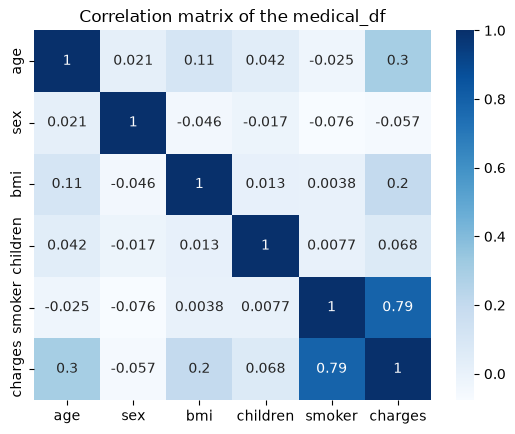

In [563]:
sns.heatmap(medical_df.corr(), cmap="Blues", annot=True)
plt.title("Correlation matrix of the medical_df")

In [564]:
def esitmated_charges(age, w, b):
    return w*age+b

In [565]:
ages = medical_df.age

In [566]:
def try_parameters(w, b):
    return esitmated_charges(ages, w, b)

In [567]:
excepted_charges = try_parameters(300, -5000)

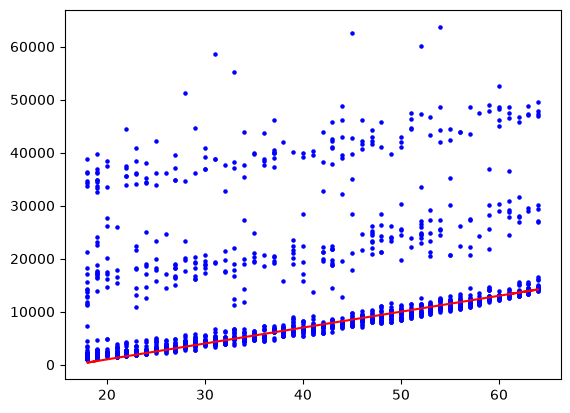

In [568]:
plt.plot(ages, excepted_charges, color='red')
plt.scatter(ages, medical_df.charges, color='blue', s=5)
plt.show()

In [569]:
excepted_charges

0         700
1         400
2        3400
3        4900
4        4600
        ...  
1333    10000
1334      400
1335      400
1336     1300
1337    13300
Name: age, Length: 1338, dtype: int64

In [570]:
medical_df.charges

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

### Linear Regression in one variable

In [571]:
from sklearn.linear_model import LinearRegression

In [572]:
model = LinearRegression()

In [573]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



In [574]:
inputs = medical_df[['age']]
targets = medical_df['charges']

In [575]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[257.72]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['age']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3166
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [576]:
model.predict(np.array([[30], [25], [19]]))

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10897.56356607,  9608.95047274,  8062.61476073])

In [577]:
targets

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [578]:
predictions = model.predict(inputs)
predictions

array([ 8062.61476073,  7804.89214207, 10382.11832874, ...,
        7804.89214207,  8578.05999807, 18886.96474474], shape=(1338,))

In [579]:
from sklearn.metrics import root_mean_squared_error

In [580]:
rmse = root_mean_squared_error(targets, predictions)
rmse

11551.66562075632

In [581]:
# w
model.coef_

array([257.72261867])

In [582]:
# b
model.intercept_

np.float64(3165.8850060630284)

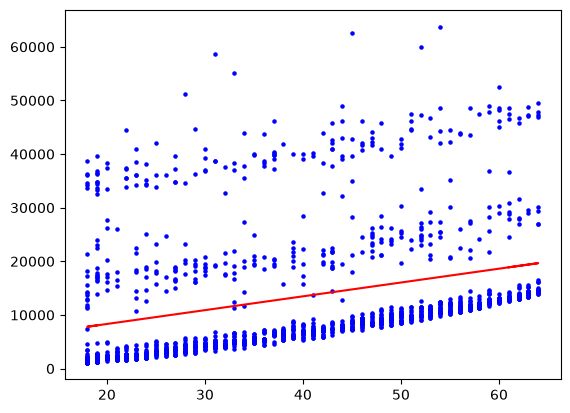

In [583]:
plt.plot(ages, predictions, color='red')
plt.scatter(ages, medical_df.charges, color='blue', s=5)
plt.show()

In [584]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [585]:
# SGD is highly sensitive to feature scaling, so always use a StandardScaler
sgd_pipeline = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
)

# Train the model
sgd_pipeline.fit(inputs, targets)

# Predict new values
sgd_pipeline.predict(np.array([[30], [25], [19]]))


c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([10962.75241578,  9672.50212584,  8124.2017779 ])

In [586]:
predictions1 = sgd_pipeline.predict(inputs)
predictions1

array([ 8124.2017779 ,  7866.15171992, 10446.6522998 , ...,
        7866.15171992,  8640.30189388, 18962.30421343], shape=(1338,))

In [587]:
rmse1 = root_mean_squared_error(targets, predictions1)
rmse1

11551.867878943927

### Linear Regression using mutiple features

In [588]:
from sklearn.linear_model import LinearRegression

In [589]:
inputs = medical_df[['age', 'bmi', 'children']]
targets = medical_df['charges']

In [590]:
model2 = LinearRegression()

In [591]:
model2.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[239.99,332.08,542.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['age','bmi','children']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-6916
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [592]:
predictions = model2.predict(inputs)
predictions

array([ 6908.77753344,  9160.97706103, 12390.94691779, ...,
        9640.92917145,  6691.39141657, 17377.08299024], shape=(1338,))

In [593]:
loss = root_mean_squared_error(targets, predictions)
loss

11355.317901125973

In [594]:
fig = px.scatter(
    medical_df,
    x = 'bmi',
    y = 'charges',
    title="bmi v/s charges"
)

fig.update_traces(marker_size = 5)
fig.show()

In [595]:
model.coef_, model.intercept_

(array([257.72261867]), np.float64(3165.8850060630284))

#### Considering Categorical data

In [596]:
medical_df = pd.read_csv("medical_data.csv")

In [597]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [598]:
medical_df['smoker'] = medical_df.smoker.map({'yes': 1, 'no': 0})
medical_df['sex'] = medical_df.sex.map({'female': 1, 'male': 0})

In [599]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [600]:
model = LinearRegression()

In [601]:
inputs = medical_df[['age', 'bmi', 'children', 'smoker', 'sex']]
targets = medical_df['charges']

In [602]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 257.73, 322.36, 474.41,23823.39, 128.64]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['age','bmi','children','smoker','sex']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.218e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [603]:
predictions = model.predict(inputs)
predictions

array([25661.85689486,  3818.77858262,  7096.73025538, ...,
        4465.88909619,  1676.96948913, 36863.89250792], shape=(1338,))

In [604]:
loss = root_mean_squared_error(targets, predictions)
loss

6056.100708754546

#### Using One-hot encoding for region

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25376\2519110000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = medical_df, x = 'region', y='charges', palette = ['red', 'green', 'blue', 'yellow'])


<Axes: xlabel='region', ylabel='charges'>

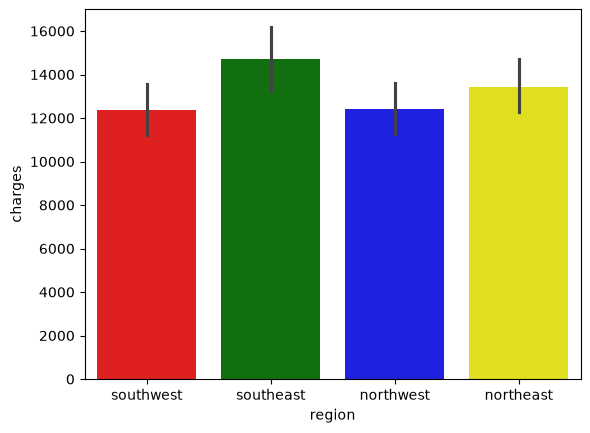

In [605]:
# checking if regions have impact on the charges

sns.barplot(data = medical_df, x = 'region', y='charges', palette = ['red', 'green', 'blue', 'yellow'])

In [606]:
from sklearn import preprocessing

In [607]:
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[['region']])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [608]:
one_hot = enc.transform(medical_df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [609]:
enc.transform([['northwest'], ['northeast']]).toarray()

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[0., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [610]:
medical_df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,southwest,16884.92400,0.0,0.0,0.0,1.0
1,18,0,33.770,1,0,southeast,1725.55230,0.0,0.0,1.0,0.0
2,28,0,33.000,3,0,southeast,4449.46200,0.0,0.0,1.0,0.0
3,33,0,22.705,0,0,northwest,21984.47061,0.0,1.0,0.0,0.0
4,32,0,28.880,0,0,northwest,3866.85520,0.0,1.0,0.0,0.0


In [611]:
medical_df['northwest'] = medical_df['northwest'].astype(int)
medical_df['northeast'] = medical_df['northeast'].astype(int)
medical_df['southwest'] = medical_df['southwest'].astype(int)
medical_df['southeast'] = medical_df['southeast'].astype(int)

In [612]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,southwest,16884.92400,0,0,0,1
1,18,0,33.770,1,0,southeast,1725.55230,0,0,1,0
2,28,0,33.000,3,0,southeast,4449.46200,0,0,1,0
3,33,0,22.705,0,0,northwest,21984.47061,0,1,0,0
4,32,0,28.880,0,0,northwest,3866.85520,0,1,0,0


In [613]:
inputs = medical_df[['age', 'sex', 'bmi', 'children', 'smoker', 'northeast', 'northwest', 'southeast', 'southwest']]
targets = medical_df.charges

In [614]:
model = LinearRegression()

In [615]:
model.fit(inputs, targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 256.86, 131.31, 339.19,..., 234.05,-448.01,-373.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['age','sex','bmi',...,'northwest','southeast','southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.266e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [616]:
predictions = model.predict(inputs)
predictions

array([25293.7130284 ,  3448.60283431,  6706.9884907 , ...,
        4149.13248568,  1246.58493898, 37085.62326757], shape=(1338,))

In [617]:
targets

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [618]:
loss = root_mean_squared_error(targets, predictions)
loss

6041.679651174452

In [619]:
model.coef_

array([  256.85635254,   131.3143594 ,   339.19345361,   475.50054515,
       23848.53454191,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [620]:
model.intercept_

np.float64(-12656.862170590553)

In [621]:
loss = root_mean_squared_error(targets, predictions)
loss

6041.679651174452